In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import math
# 1. Set up the connection credentials
username = 'root'
password = 'anurag20078690' 
host = 'localhost'
database = 'hr_analytics'

# 2. Create the engine (The bridge to MySQL)
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

df = pd.read_sql('select * from employees_data;',engine)
df.head()

,l,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StandardHours,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,Life Sciences,1,1,2,...,3,1,80,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Life Sciences,1,2,3,...,4,4,80,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,Other,1,4,4,...,3,2,80,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Life Sciences,1,5,4,...,3,3,80,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Medical,1,7,1,...,3,4,80,6,3,3,2,2,2,2


### Exploritory Data Analysis
-> In the pervious EDA We have Removed Unnecessary rows that were not needed in the analysis


-> in this EDA we are going to analyse the research question and find out the actual problem currently the company is facing for its employees turnover

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
l,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


Plotting 24 numerical columns:
['l', 'DailyRate', 'DistanceFromHome', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


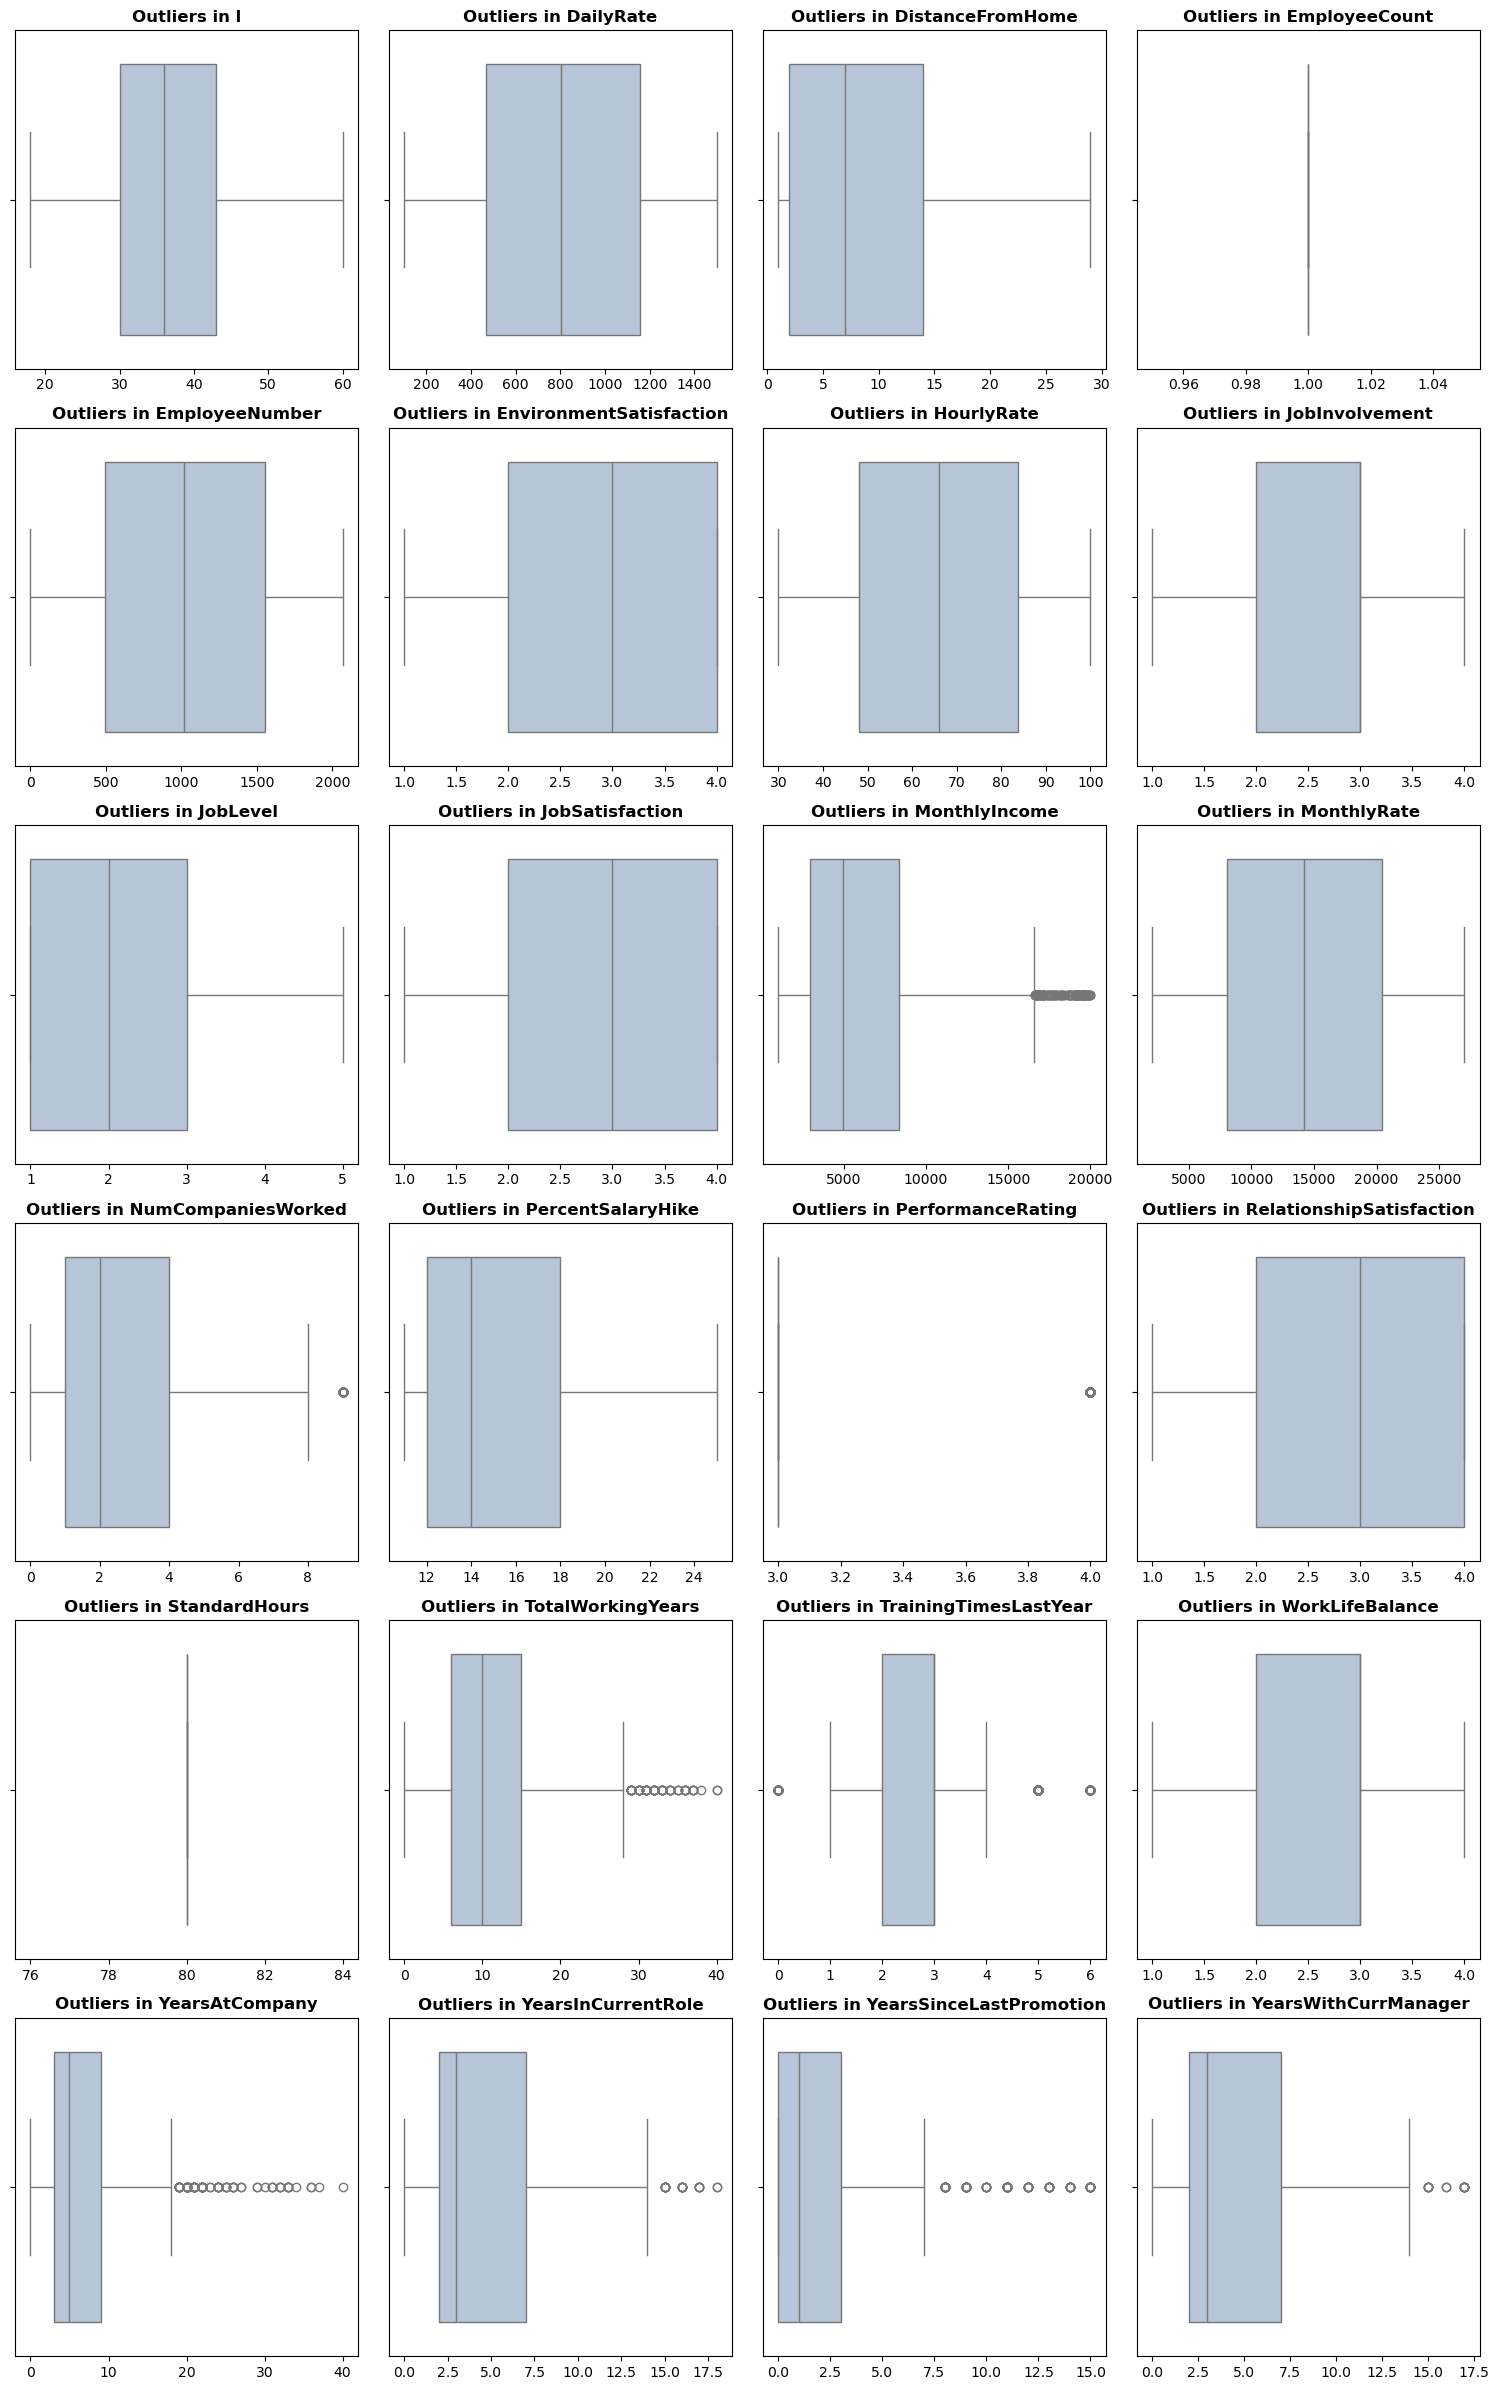

In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Plotting {len(numerical_cols)} numerical columns:\n{numerical_cols}")

# 2. Setup the dynamic grid
cols = 4
# FIXED: Divide the number of columns (not the whole dataframe!)
rows = math.ceil(len(numerical_cols) / cols) 

# FIXED: Combine figure size and subplots into one clean line
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() 

# 3. Draw the boxplots
for i, col in enumerate(numerical_cols):
    # FIXED: Added x= to prevent Seaborn warnings
    sns.boxplot(x=df[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(f"Outliers in {col}", fontweight='bold')
    axes[i].set_xlabel('')

# 4. Hide empty subplots if the math doesn't divide perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

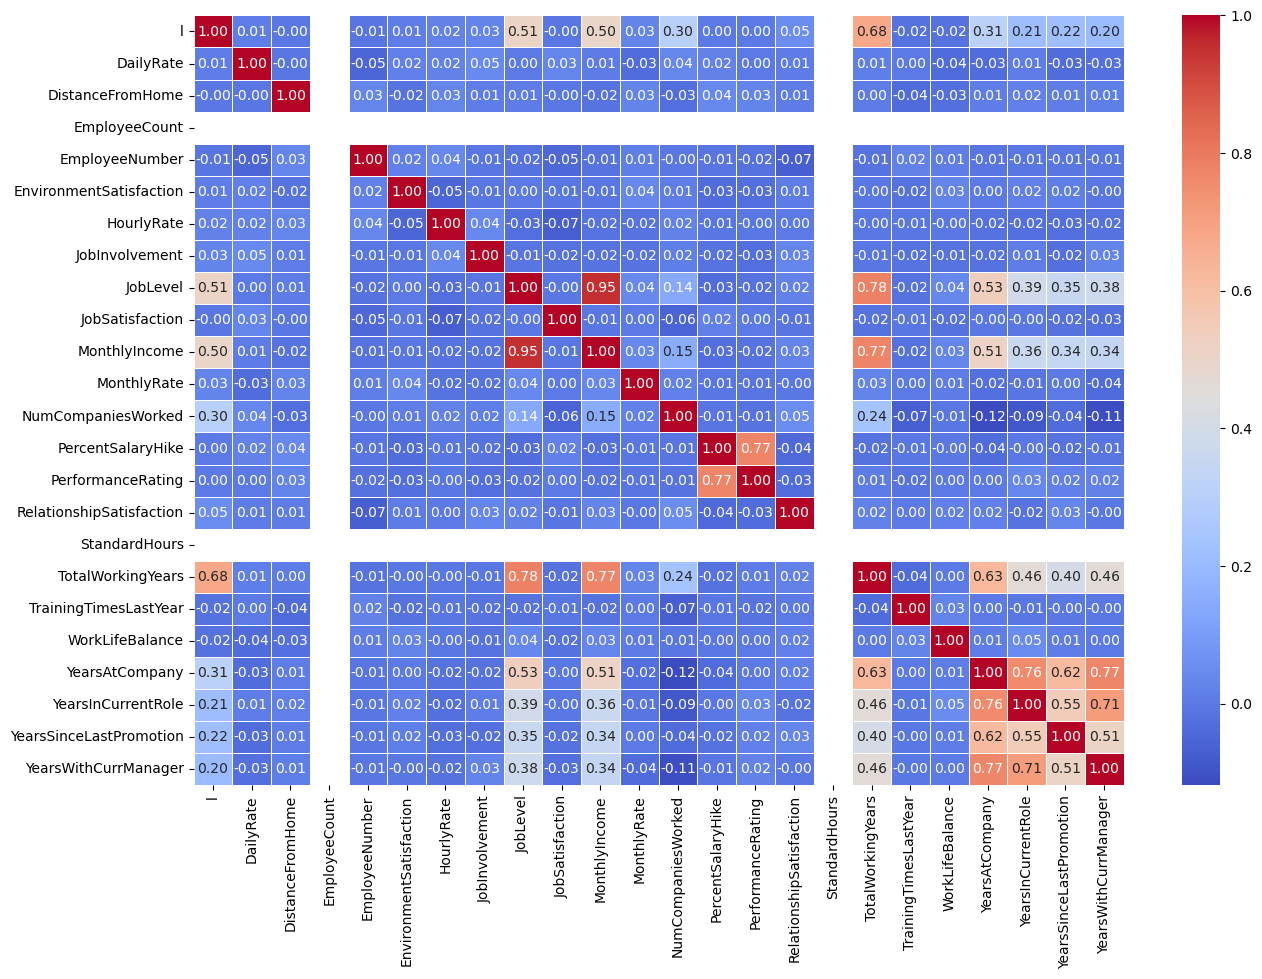

In [5]:
plt.figure(figsize = (15,10))
correrlation_matrix = df.select_dtypes(include = 'int64').corr()
sns.heatmap(correrlation_matrix,cmap = 'coolwarm',annot = True,fmt = '.2f',linewidth = 0.5)
plt.show()

### Part 1: The Baseline Profile

#### Q1: What is the average Monthly Income, Performance Rating, and overall Attrition Rate for each Department?

In [8]:
query = """
    SELECT 
        Department, 
        AVG(MonthlyIncome) as Average_income,
        AVG(PerformanceRating) as Average_rating,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)/COUNT(*)*100,2) AS 'Attrition_Rate'
    fROM employees_data 
    GROUP BY Department;
    """
df1 = pd.read_sql(query,engine)
df1

,Department,Average_income,Average_rating,Attrition_Rate
0,Sales,6959.1726,3.1368,20.63
1,Research & Development,6281.2529,3.1623,13.84
2,Human Resources,6654.5079,3.1429,19.05


#### Q2: On average, how many years does an employee spend in their current role, and at the company overall?

In [10]:
query_2 ="""
    SELECT
        JobRole,
        Department,
        AVG(YearsInCurrentRole) as Average_years_in_role,
        AVG(YearsAtCompany) as Average_years_in_compnay
    FROM employees_data
    GROUP BY JobRole,Department;
    """
df2 = pd.read_sql(query_2,engine)
print(df2)

                      JobRole              Department  Average_years_in_role  \
0             Sales Executive                   Sales                 4.8558   
1          Research Scientist  Research & Development                 3.2740   
2       Laboratory Technician  Research & Development                 3.2008   
3      Manufacturing Director  Research & Development                 4.9724   
4   Healthcare Representative  Research & Development                 4.8626   
5                     Manager                   Sales                 6.7838   
6        Sales Representative                   Sales                 2.0120   
7           Research Director  Research & Development                 6.2875   
8                     Manager  Research & Development                 6.4259   
9             Human Resources         Human Resources                 3.1346   
10                    Manager         Human Resources                 5.4545   

    Average_years_in_compnay  
0       

### Part 2: The Effort & Burnout Indicators 

#### Q3: What percentage of our workforce is currently working Overtime, and which department relies on Overtime the most

In [13]:
query_3 = """
    SELECT
        Department,
         ROUND(COUNT(CASE WHEN OverTime = 'Yes' THEN 1 END) * 100.0 / COUNT(*)) as OverTime
        fROM employees_data
        GROUP BY Department; 
    """
df3 = pd.read_sql(query_3,engine)
df3

,Department,OverTime
0,Sales,29.0
1,Research & Development,28.0
2,Human Resources,27.0


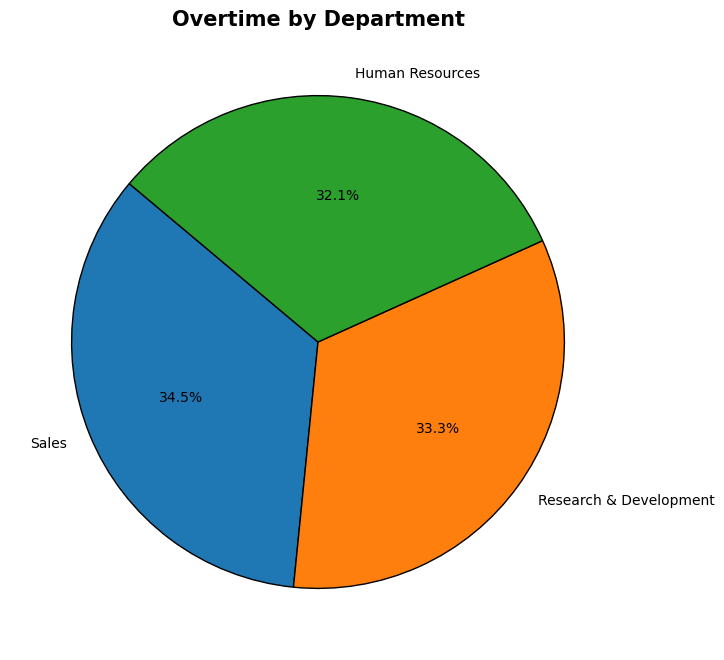

In [14]:
import matplotlib.pyplot as plt

# 1. Set up a perfectly square canvas (so the pie isn't stretched into an oval)
plt.figure(figsize=(8, 8))

# 3. Draw the Pie Chart using your exact column names
plt.pie(
    df3['OverTime'],                 # The numbers (sizes of the slices)
    labels=df3['Department'], 
    center = (0,0),# The text labels for each slice            
    autopct='%0.1f%%',               # Automatically calculates and prints the % on the slices
    startangle=140,                  # Rotates the pie slightly for a better visual balance
    wedgeprops={'edgecolor': 'black'}# Draws a crisp black line around each slice
)

# 4. Add a bold, executive title
plt.title('Overtime by Department', fontsize=15, fontweight='bold')

# 5. Render the final graph!
plt.show()

### Part 3: The Reward Disconnect 

#### Q4: Do employees who work Overtime actually receive a higher Monthly Income or a higher percentage Salary Hike than those who do not?

In [17]:
query_4 = """
    SELECT
        JobRole,
        Department,
        OverTime,
        COUNT(EmployeeNumber) AS Headcount,
        AVG(MonthlyIncome) AS AverageIncome,
        AVG(PercentSalaryHike) AS Average_Percentage_hike
    FROM employees_data
    GROUP BY 
        Department,
        JobRole,
        Overtime
    ORDER BY 
        Department,
        JobRole,
        Overtime;
    """
df_4 = pd.read_sql(query_4,engine)
df_4

,JobRole,Department,OverTime,Headcount,AverageIncome,Average_Percentage_hike
0,Human Resources,Human Resources,No,39,4202.6923,14.7949
1,Human Resources,Human Resources,Yes,13,4334.9231,14.8462
2,Manager,Human Resources,No,7,18792.5714,14.0000
3,Manager,Human Resources,Yes,4,16856.7500,15.5000
4,Healthcare Representative,Research & Development,No,94,7412.3617,15.7553
5,Healthcare Representative,Research & Development,Yes,37,7824.4865,14.6757
6,Laboratory Technician,Research & Development,No,197,3195.2335,15.0406
7,Laboratory Technician,Research & Development,Yes,62,3370.4194,15.0645
8,Manager,Research & Development,No,41,17312.9268,15.3171
9,Manager,Research & Development,Yes,13,16554.4615,13.6923


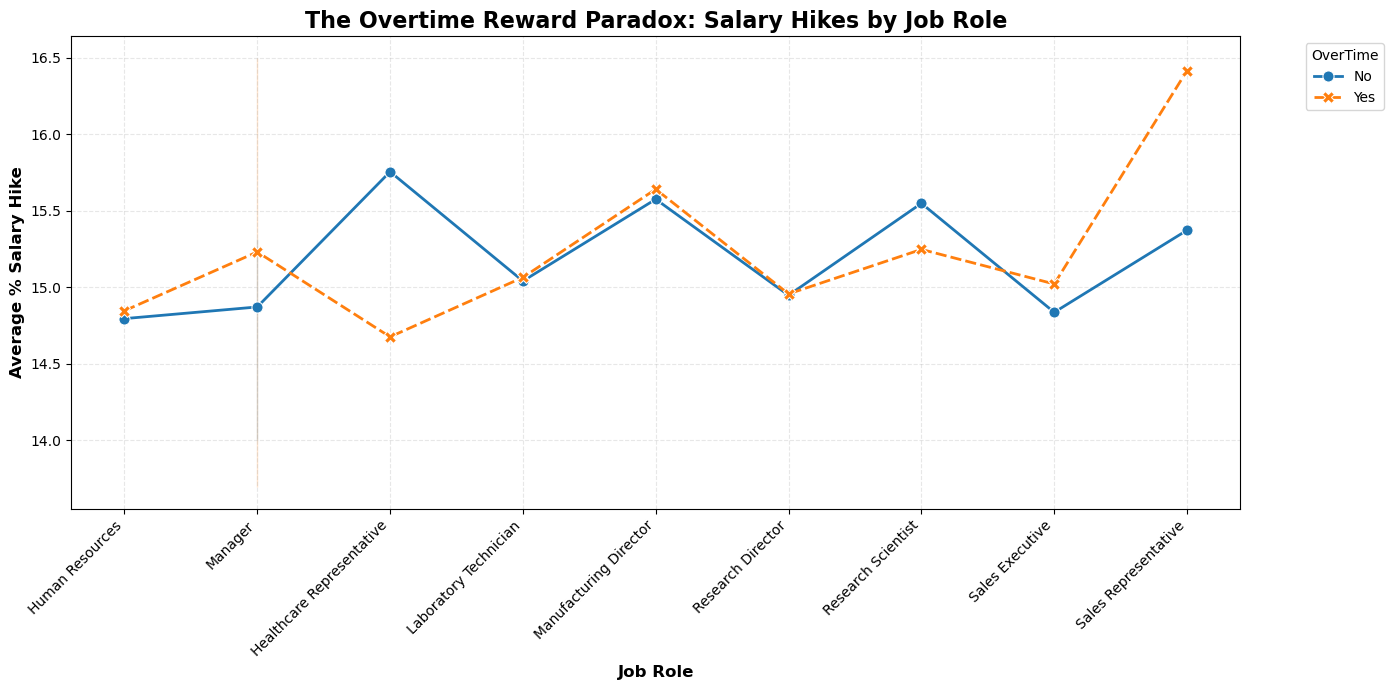

In [18]:
plt.figure(figsize = (14,7))

sns.lineplot(
    data=df_4,
    x='JobRole',
    y='Average_Percentage_hike', 
    hue='OverTime',
    style='OverTime',
    markers=True,
    dashes=True,
    linewidth=2,
    markersize=8
)
plt.title('The Overtime Reward Paradox: Salary Hikes by Job Role', fontsize=16, fontweight='bold')
plt.xlabel('Job Role', fontsize=12, fontweight='bold')
plt.ylabel('Average % Salary Hike', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.legend(title='OverTime', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### Q5: Do employees who stay loyal to the company for 5+ years receive higher performance ratings and salary hikes, or do they stagnate compared to newer employees?

In [20]:

query_5 = """
    SELECT
        CASE
            WHEN YearsAtCompany BETWEEN 0 AND 5 THEN '01. NEW(0-5 YEARS)'
            WHEN YearsAtCompany BETWEEN 6 AND 10 THEN '02. MID(6-10 YEARS)'
            WHEN YearsAtCompany BETWEEN 11 AND 15 THEN '03. SENIOR(11-15 YEARS)'
            ELSE '04. VETERAN (16+ YEARS)'
        END AS Years_At_Company,
        ROUND(AVG(MonthlyIncome),2) AS Average_Income,
        ROUND(AVG(PercentSalaryHike),2) AS Average_Hike,
        ROUND(AVG(PerformanceRating),2) AS Average_Rating
    FROM employees_data
    GROUP BY
        CASE
            WHEN YearsAtCompany BETWEEN 0 AND 5 THEN '01. NEW(0-5 YEARS)'
            WHEN YearsAtCompany BETWEEN 6 AND 10 THEN '02. MID(6-10 YEARS)'
            WHEN YearsAtCompany BETWEEN 11 AND 15 THEN '03. SENIOR(11-15 YEARS)'
            ELSE '04. VETERAN (16+ YEARS)'
        END
    ORDER BY Years_At_Company;
"""
df_5 = pd.read_sql(query_5,engine)
df_5

,Years_At_Company,Average_Income,Average_Hike,Average_Rating
0,01. NEW(0-5 YEARS),5075.97,15.31,3.15
1,02. MID(6-10 YEARS),6567.37,15.00,3.14
2,03. SENIOR(11-15 YEARS),7728.81,15.67,3.22
3,04. VETERAN (16+ YEARS),13358.40,14.93,3.14


C:\Users\anura\AppData\Local\Temp\ipykernel_20584\1996455591.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


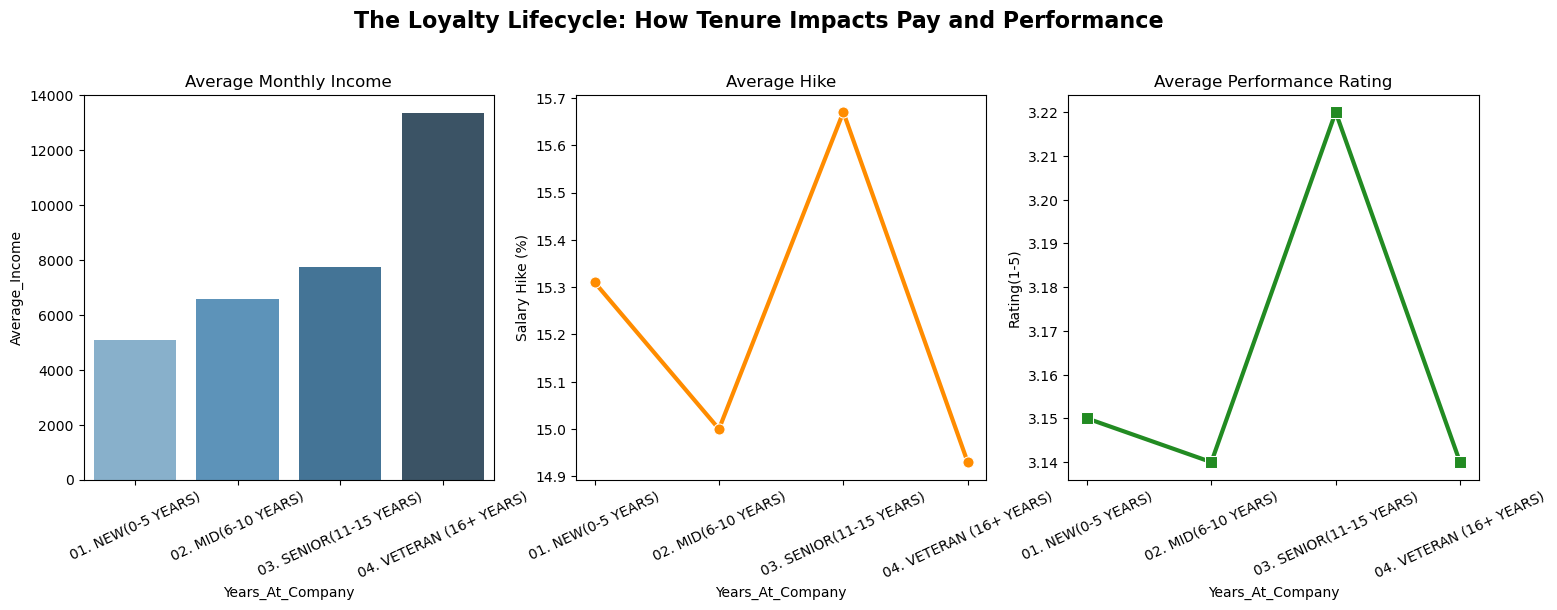

<Figure size 640x480 with 0 Axes>

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(
    data=df_5, 
    x='Years_At_Company', 
    y='Average_Income', 
    ax=axes[0],
    palette = 'Blues_d'
)
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_title('Average Monthly Income')
axes[0].set_ylabel('Average_Income')

sns.lineplot(
    data = df_5,
    x = 'Years_At_Company',
    y = 'Average_Hike',
    ax = axes[1],
    marker = 'o',
    markersize = 8,
    linewidth = 3,
    color = 'darkorange'
)
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_title('Average Hike')
axes[1].set_ylabel('Salary Hike (%)')

sns.lineplot(
    data = df_5,
    x = 'Years_At_Company',
    y = 'Average_Rating',
    ax = axes[2],
    marker = 's',
    markersize = 8,
    linewidth = 3,
    color = 'forestgreen'
)
axes[2].tick_params(axis='x', rotation=25)
axes[2].set_title('Average Performance Rating')
axes[2].set_ylabel('Rating(1-5)')

fig.suptitle('The Loyalty Lifecycle: How Tenure Impacts Pay and Performance', fontsize=16, fontweight='bold', y=1.05)
plt.show()
plt.tight_layout()

### Part 4: The Flight Risk

#### Q6: Is the company relying on top-performers who have terrible Work-Life Balance? If so, what is their Attrition rate?

In [24]:
query_6 = """
    SELECT
        Department,
        PerformanceRating,
        WorkLifeBalance,
        COUNT(EmployeeCount) AS Total_Employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Total_Quit,
        ROUND(COUNT(CASE WHEN Attrition = 'Yes' THEN 1 END)*100/COUNT(*)) AS Attrition_pct
    FROM employees_data
    GROUP BY 
        PerformanceRating,
        WorkLifeBalance,
        Department
    ORDER BY 
        PerformanceRating DESC,
        WorkLifeBalance ASC,
        CASE Department 
            WHEN 'Human Resources' THEN 1
            WHEN 'Sales' THEN 2
            WHEN 'Research & Development' THEN 3
        END ASC;
"""
df_6 = pd.read_sql(query_6,engine)
df_6

,Department,PerformanceRating,WorkLifeBalance,Total_Employees,Total_Quit,Attrition_pct
0,Sales,4,1,3,0.0,0.0
1,Research & Development,4,1,11,5.0,45.0
2,Human Resources,4,2,1,0.0,0.0
3,Sales,4,2,19,3.0,16.0
4,Research & Development,4,2,28,3.0,11.0
5,Human Resources,4,3,6,1.0,17.0
6,Sales,4,3,31,4.0,13.0
7,Research & Development,4,3,104,13.0,13.0
8,Human Resources,4,4,2,0.0,0.0
9,Sales,4,4,8,3.0,38.0


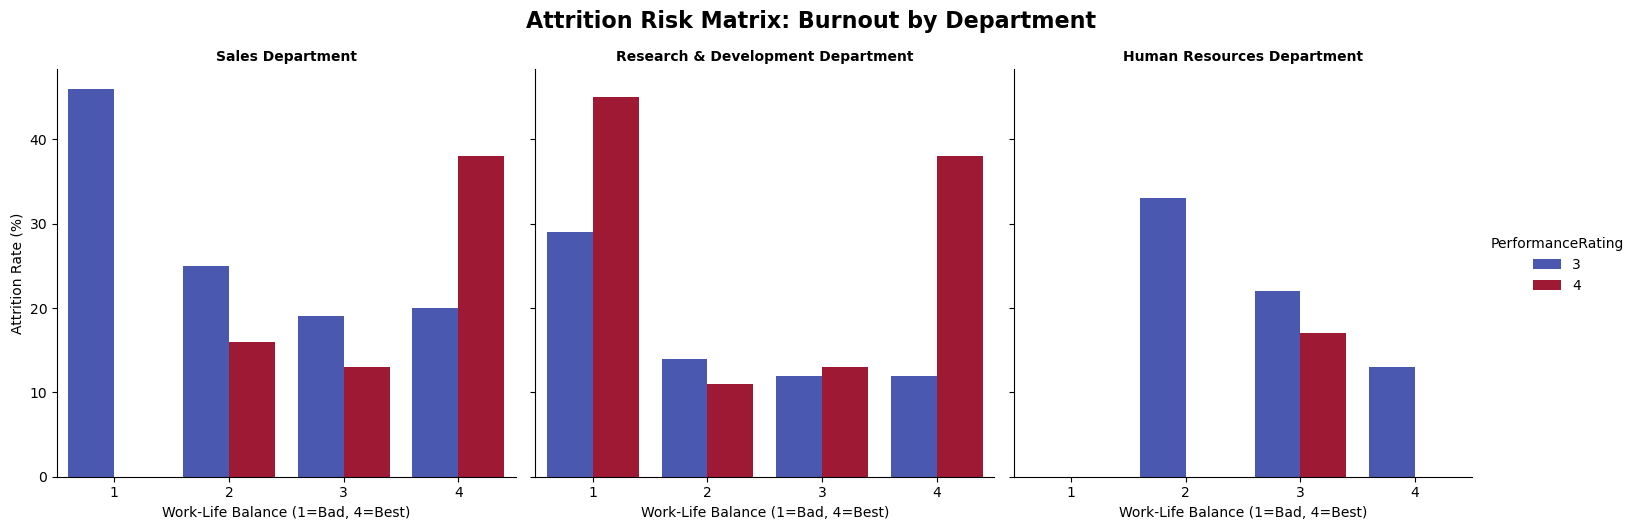

In [25]:
graph = sns.catplot(
    data = df_6,
    x = 'WorkLifeBalance',
    y = 'Attrition_pct',
    hue = 'PerformanceRating',
    col = 'Department',
    kind = 'bar',
    palette = 'coolwarm'
)
graph.fig.suptitle('Attrition Risk Matrix: Burnout by Department', y=1.05, fontsize=16, fontweight='bold')
graph.set_axis_labels('Work-Life Balance (1=Bad, 4=Best)', 'Attrition Rate (%)')
graph.set_titles("{col_name} Department", fontweight='bold')
plt.show()

#### Q7: When an employee is in the "High Effort" bucket (Overtime = Yes) but the "Low Reward" bucket (Low Salary Hike), how much higher is their Attrition Rate compared to the rest of the company? Which department is bleeding the most talent because of this?

In [44]:
query_7 = """
    SELECT
        Department,
        
        -- 1. Create the custom logic buckets using AND
        CASE 
            WHEN OverTime = 'Yes' AND PercentSalaryHike <= 14 THEN '01. High Effort & Low Reward'
            ELSE '02. Rest of the Team'
        END AS Employee_Category,
        
        -- 2. Basic Headcount and Quit numbers
        COUNT(EmployeeNumber) AS Headcount,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Total_Quit,
        
        -- 3. The critical Attrition Percentage
        ROUND(COUNT(CASE WHEN Attrition = 'Yes' THEN 1 END) * 100.0 / COUNT(*), 2) AS Attrition_Rate
        
    FROM employees_data
    GROUP BY 
        Department,
        CASE 
            WHEN OverTime = 'Yes' AND PercentSalaryHike <= 14 THEN '01. High Effort & Low Reward'
            ELSE '02. Rest of the Team'
        END
    ORDER BY 
        Department ASC,
        Employee_Category ASC;
"""

df_7 = pd.read_sql(query_7, engine)
print("--- THE BURNOUT & BETRAYAL MATRIX ---")
print(df_7)

--- THE BURNOUT & BETRAYAL MATRIX ---
               Department             Employee_Category  Headcount  \
0         Human Resources  01. High Effort & Low Reward          8   
1         Human Resources          02. Rest of the Team         55   
2  Research & Development  01. High Effort & Low Reward        160   
3  Research & Development          02. Rest of the Team        801   
4                   Sales  01. High Effort & Low Reward         73   
5                   Sales          02. Rest of the Team        373   

   Total_Quit  Attrition_Rate  
0         2.0           25.00  
1        10.0           18.18  
2        42.0           26.25  
3        91.0           11.36  
4        29.0           39.73  
5        63.0           16.89  


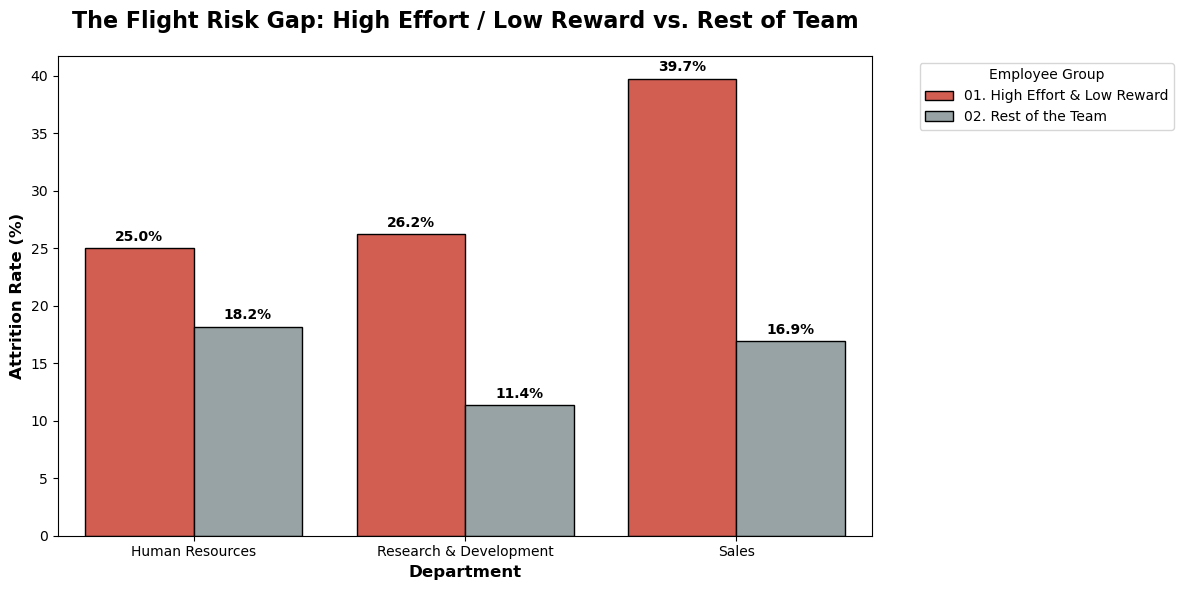

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
custom_palette = ['#e74c3c', '#95a5a6'] 
ax = sns.barplot(
    data=df_7,
    x='Department',
    y='Attrition_Rate',
    hue='Employee_Category',
    palette=custom_palette,
    edgecolor='black',       
    linewidth=1
)

plt.title('The Flight Risk Gap: High Effort / Low Reward vs. Rest of Team', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=12, fontweight='bold')
plt.ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
plt.legend(title='Employee Group', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')
plt.tight_layout()
plt.show()